Understanding the Difference Between Embedding Layers and Linear Layers

In [ ]:
import torch

# 中文：导入 PyTorch，并打印版本号，确认当前运行环境的 torch 版本
print("PyTorch version:", torch.__version__)

Using nn.Embedding

In [ ]:
# Suppose we have the following 3 training examples,
# which may represent token IDs in a LLM context
# 中文：假设这是 3 个训练样本对应的 token ID，是形状为 (3,) 的一维张量，
# 每个元素表示词表中的一个索引位置（例如 2 表示词表里第 3 个 token，索引从 0 开始）

idx=torch.tensor([2,3,1])


# The number of rows in the embedding matrix can be determined
# by obtaining the largest token ID + 1.
# If the highest token ID is 3, then we want 4 rows, for the possible
# token IDs 0, 1, 2, 3
# 中文：嵌入矩阵的行数 = 最大 token ID + 1。因为 token ID 从 0 开始编号，
# 要覆盖 0、1、2、3 这 4 个可能出现的 ID，就需要 4 行，即词表大小

num_idx=max(idx)+1

# The desired embedding dimension is a hyperparameter
# 中文：每个 token 用一个长度为 5 的向量表示，即嵌入维度，是一个可自行设定的超参数

out_dim = 5

In [ ]:
# We use the random seed for reproducibility since
# weights in the embedding layer are initialized with
# small random values
# 中文：固定随机种子，保证嵌入层权重的随机初始化结果可复现
torch.manual_seed(123)

# 中文：创建嵌入层（查找表），权重矩阵形状为 (num_idx=4, out_dim=5)，
# 即词表中共有 4 个 token，每个 token 对应权重矩阵中的一行、长度为 5 的向量
embedding = torch.nn.Embedding(num_idx, out_dim)

In [ ]:
# 中文：查看嵌入层内部的权重矩阵（即“查找表”），形状为 (4, 5)：
# 4 行分别对应 token ID 0、1、2、3，每行是该 token 的嵌入向量；
# 该权重默认 requires_grad=True，训练时会随梯度更新
embedding.weight

In [ ]:
# 中文：用 token ID=1 作为索引去“查表”，等价于直接取出权重矩阵中第 1 行（从 0 开始计数）
# 输入形状为 (1,)，输出形状为 (1, 5)
embedding(torch.tensor([1]))

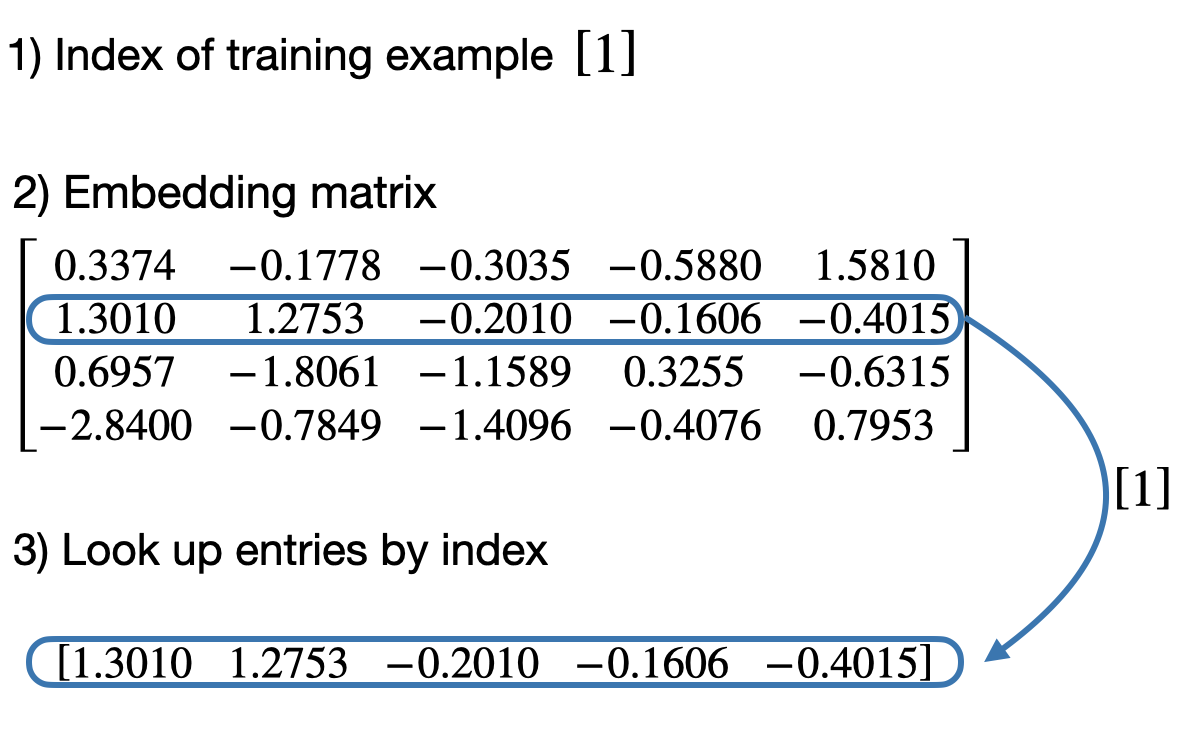

In [ ]:
# 中文：同理，用 token ID=2 查表，取出权重矩阵第 2 行，输出形状为 (1, 5)
embedding(torch.tensor([2]))

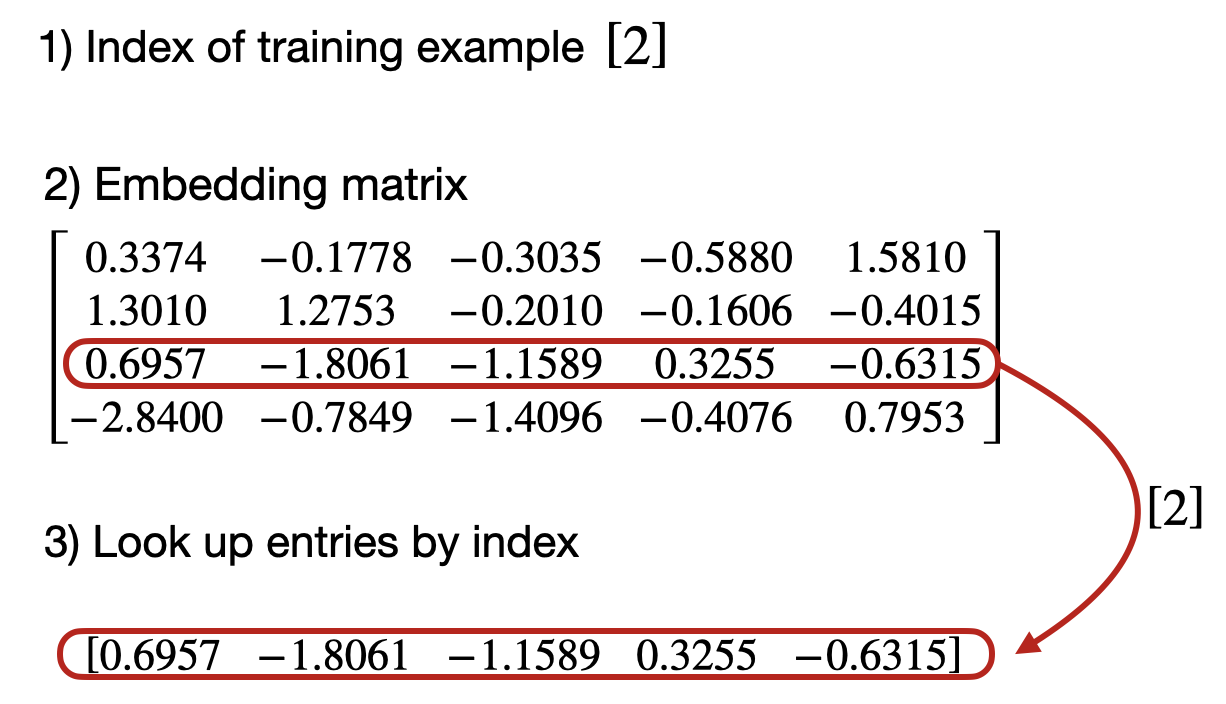

In [ ]:
# 中文：一次性对多个 token ID 做批量查表。
# idx 形状为 (3,)，取值为 [2, 3, 1]；
# 输出形状为 (3, 5)，依次是权重矩阵第 2、3、1 行拼接而成的矩阵
idx = torch.tensor([2, 3, 1])
embedding(idx)

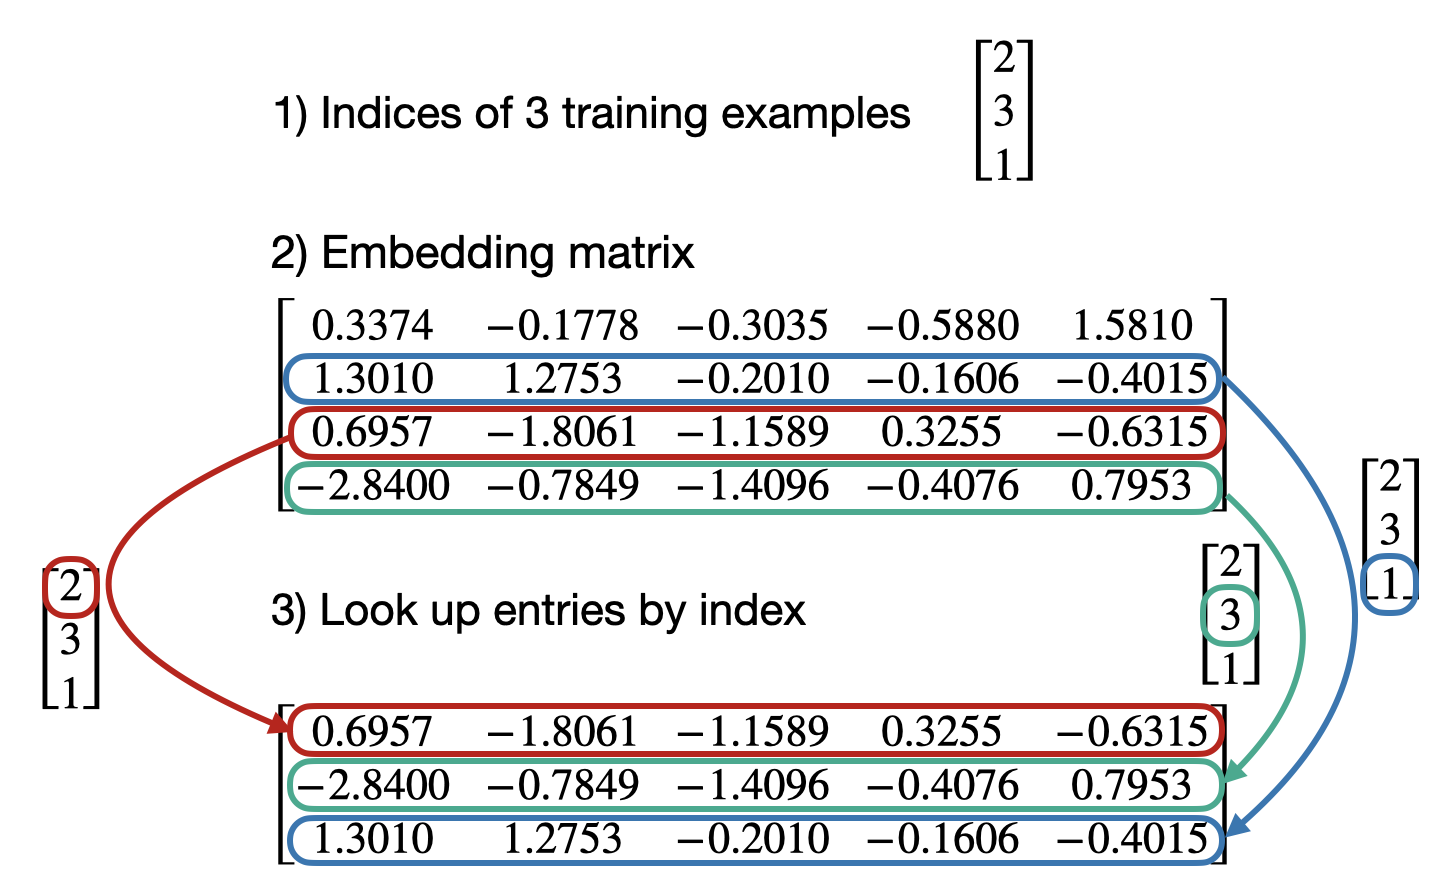

Using nn.Linear

In [ ]:
# 中文：把 idx 中每个 token ID 转成 one-hot（独热）向量。
# idx 形状为 (3,)；one_hot 默认按 idx 中最大值+1 推断类别数，这里为 4，
# 所以 onehot 形状为 (3, 4)：每一行只有对应 token ID 的那一列为 1，其余为 0
onehot = torch.nn.functional.one_hot(idx)
onehot

In [ ]:
# 中文：使用与嵌入层相同的随机种子，方便后续直接复用嵌入层的权重来验证等价性
torch.manual_seed(123)
# 中文：创建一个不带偏置（bias=False）的线性层，输入维度=num_idx=4，输出维度=out_dim=5。
# nn.Linear 权重形状为 (out_features, in_features) = (5, 4)，
# 注意这和嵌入层权重的形状 (4, 5) 正好是转置关系
linear = torch.nn.Linear(num_idx, out_dim, bias=False)
linear.weight

In [ ]:
# 中文：把嵌入层的权重转置后赋给线性层的权重，使两者在数学上等价。
# embedding.weight 形状为 (4, 5)，转置后为 (5, 4)，
# 恰好匹配 nn.Linear 权重要求的 (out_features, in_features) = (5, 4)
linear.weight = torch.nn.Parameter(embedding.weight.T)

In [ ]:
# 中文：用 one-hot 向量与线性层权重做矩阵乘法：onehot.float() 形状为 (3, 4)，
# 经过 linear（内部即 onehot @ weight.T，weight 形状 (5, 4)）后输出形状为 (3, 5)。
# 由于 one-hot 向量中只有一个位置为 1，矩阵乘法的效果等价于“挑出”权重矩阵中对应的那一行，
# 这说明 “one-hot 向量 + 线性层矩阵乘法” 与 “Embedding 直接查表” 在数学上是等价的
linear(onehot.float())

In [ ]:
# 中文：再次用 Embedding 层对相同的 idx 做查表，得到形状为 (3, 5) 的结果，
# 与上一个单元格 linear(onehot.float()) 的输出对比，二者数值应完全一致，
# 从而验证了 Embedding 查表 等价于 one-hot 向量 @ 线性层权重（矩阵乘法）
embedding(idx)

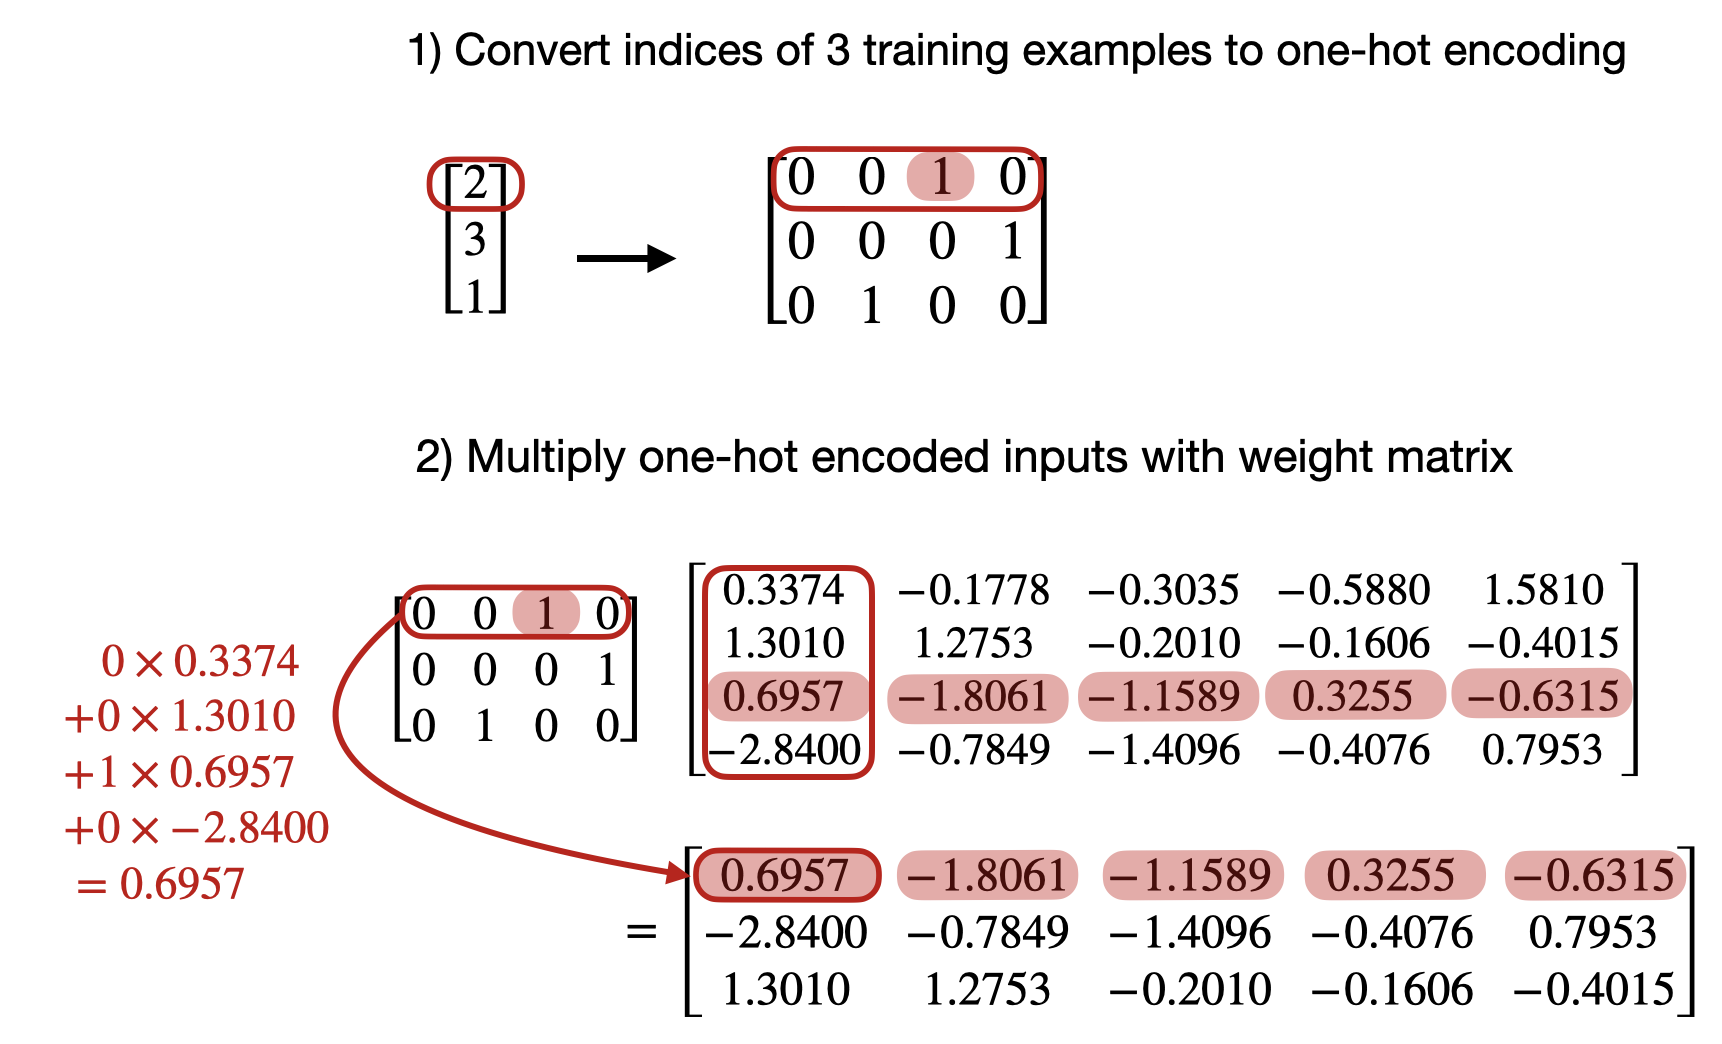

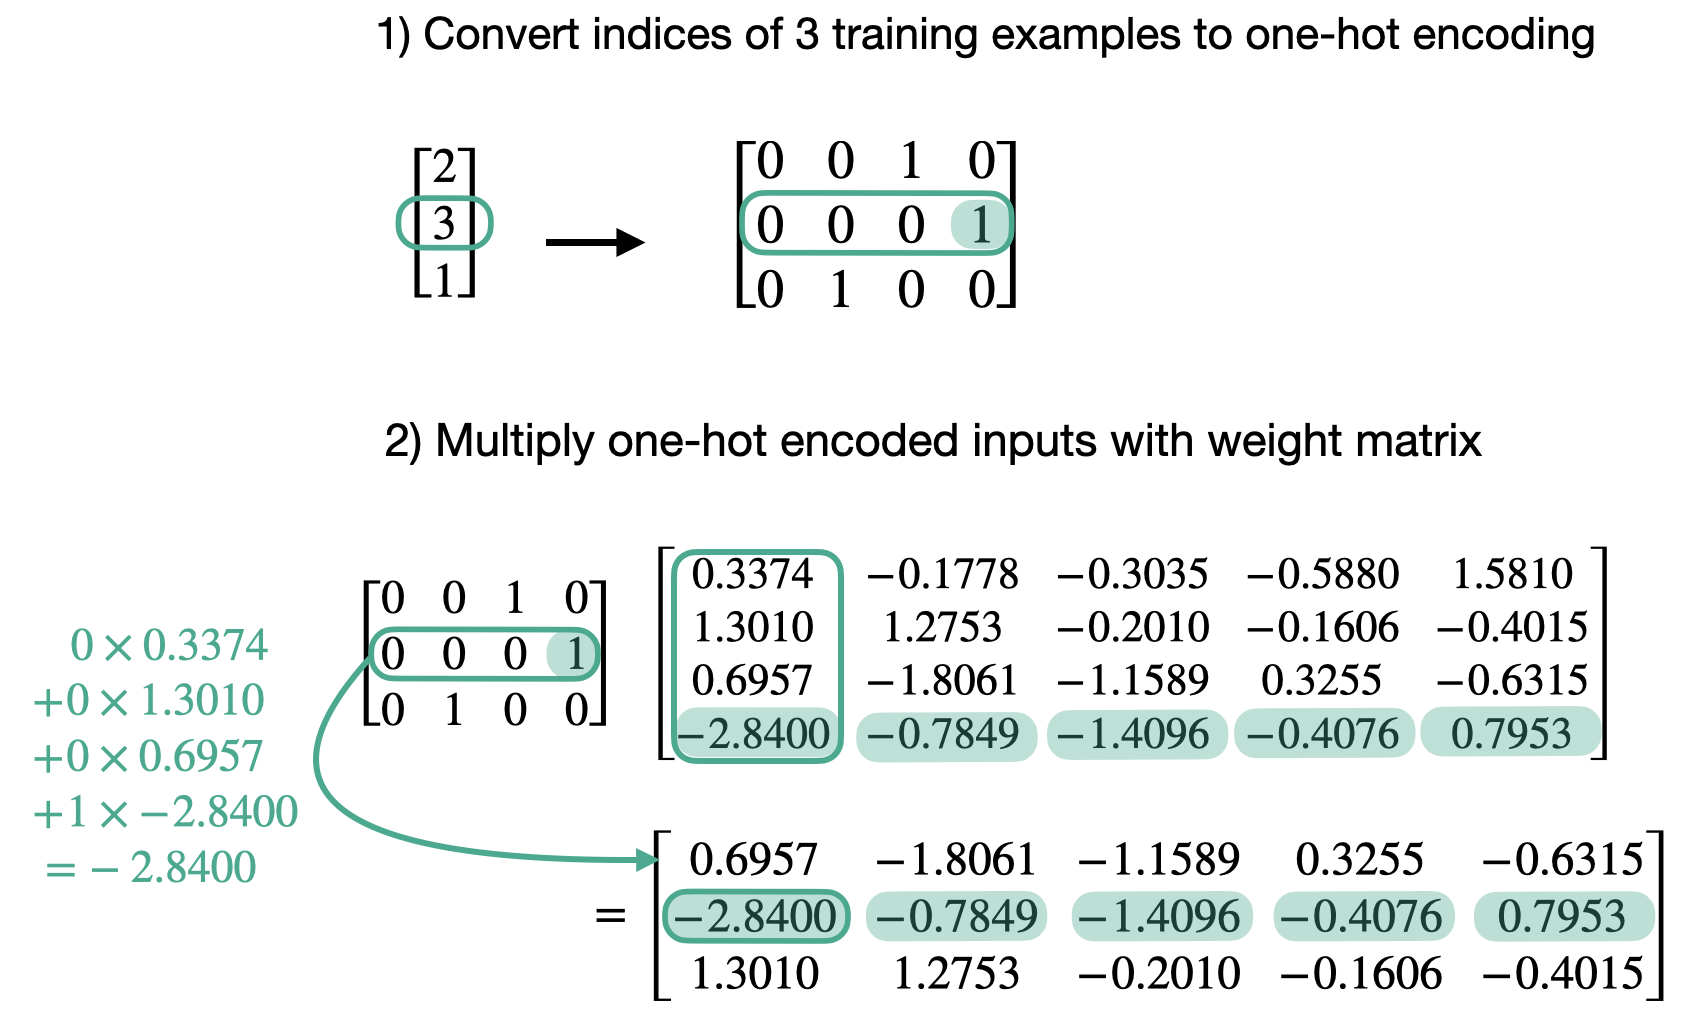